In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/AcuVisor/synthetic_acoustics_dataset.csv"
df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
df.head()


Mounted at /content/drive
Dataset shape: (6000, 15)


,L,W,H,wall_mat,floor_mat,ceil_mat,wall_a,floor_a,ceil_a,panel_coverage,alpha_eff_before,alpha_eff_after,rt60_before,rt60_after,rt60_delta
0,3.235396,3.237295,3.199114,painted_plaster,wood,painted_plaster,0.07,0.20,0.07,0.586683,0.091834,0.376250,0.235507,0.194161,0.041346
1,5.290197,3.580045,2.411505,concrete,carpet,painted_plaster,0.03,0.45,0.07,0.530684,0.138010,0.354743,0.405920,0.256471,0.149450
2,5.475890,3.973076,2.583100,painted_plaster,wood,painted_plaster,0.07,0.20,0.07,0.667682,0.100633,0.358335,0.396579,0.275357,0.121222
3,5.361752,4.693829,2.698498,painted_plaster,wood,painted_plaster,0.07,0.20,0.07,0.325311,0.101277,0.224483,0.419253,0.416140,0.003114
4,5.930785,3.424321,2.415316,concrete,wood,painted_plaster,0.03,0.20,0.07,0.524364,0.079702,0.292341,0.473995,0.342864,0.131131


In [ ]:
FEATURES = [
    "L", "W", "H",
    "wall_a", "floor_a", "ceil_a",
    "panel_coverage"
]

TARGET = "rt60_after"


In [ ]:
X = df[FEATURES].values
y = df[TARGET].values

print("Input shape:", X.shape)
print("Target shape:", y.shape)


Input shape: (6000, 7)
Target shape: (6000,)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Train: (4200, 7)
Val  : (900, 7)
Test : (900, 7)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,785 (26.50 KB)

 Trainable params: 6,785 (26.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0404 - val_loss: 0.0014
Epoch 2/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0025 - val_loss: 5.6648e-04
Epoch 3/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0013 - val_loss: 4.6774e-04
Epoch 4/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.9863e-04 - val_loss: 3.0631e-04
Epoch 5/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.5269e-04 - val_loss: 2.8146e-04
Epoch 6/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5.3335e-04 - val_loss: 3.6853e-04
Epoch 7/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.7001e-04 - val_loss: 3.4538e-04
Epoch 8/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.1910e-04 - val_loss: 2.4764e-04
Epoch 9/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.6891e-04 - val_loss: 1.9660e-04
Epoch 10/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.6547e-04 - val_loss: 1.8682e-04
Epoch 11/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss:

In [ ]:
y_pred = model.predict(X_test).flatten()

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f} s")
print(f"RMSE: {rmse:.4f} s")
print(f"R²  : {r2:.4f}")


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MAE : 0.0101 s
RMSE: 0.0129 s
R²  : 0.9624


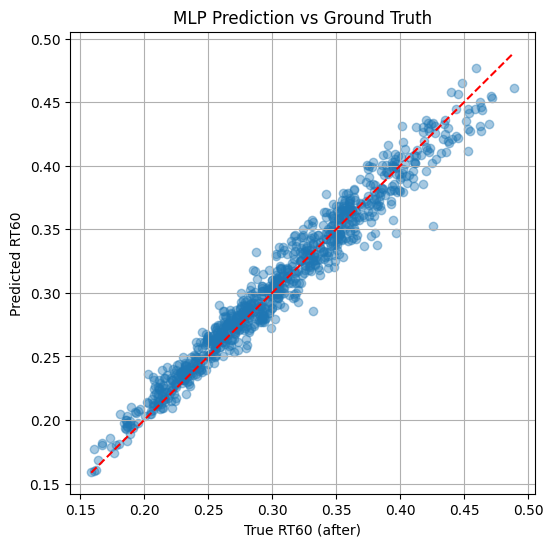

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("True RT60 (after)")
plt.ylabel("Predicted RT60")
plt.title("MLP Prediction vs Ground Truth")
plt.grid(True)
plt.show()


In [ ]:
model.save("/content/drive/MyDrive/AcuVisor/mlp_rt60_model.keras")

import joblib
joblib.dump(scaler, "/content/drive/MyDrive/AcuVisor/feature_scaler.pkl")

print("Model and scaler saved to Drive")

!ls /content/drive/MyDrive/AcuVisor


Model and scaler saved to Drive
feature_scaler.pkl  mlp_rt60_model.keras  synthetic_acoustics_dataset.csv


In [ ]:
from tensorflow.keras.models import load_model
import joblib
import numpy as np

MODEL_PATH = "/content/drive/MyDrive/AcuVisor/mlp_rt60_model.keras"
SCALER_PATH = "/content/drive/MyDrive/AcuVisor/feature_scaler.pkl"

loaded_model = load_model(MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)

# take 5 samples from your dataset and compare
X_sample = df[FEATURES].iloc[:5].values
y_true = df[TARGET].iloc[:5].values

X_sample_scaled = loaded_scaler.transform(X_sample)
y_pred = loaded_model.predict(X_sample_scaled).flatten()

print("True :", np.round(y_true, 4))
print("Pred :", np.round(y_pred, 4))
print("Abs err:", np.round(np.abs(y_true - y_pred), 4))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
True : [0.1942 0.2565 0.2754 0.4161 0.3429]
Pred : [0.1994 0.2671 0.2798 0.4008 0.3513]
Abs err: [0.0053 0.0106 0.0044 0.0154 0.0085]
